In [1]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# GPU 설정 확인
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print("GPU Enabled")
    except RuntimeError as e:
        print(e)

# Sionna Import
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera, RadioMapSolver, PathSolver
from sionna.rt import scene as share_scene # 내장 씬 로드용



2025-11-27 14:54:01.584416: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764251641.592547 1606732 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764251641.595096 1606732 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-27 14:54:01.604423: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


GPU Enabled


In [15]:
# 라디오맵 영역 설정 (예시 값)
map_center = [100.0, 100.0, 1.5]  # [x, y, z] 중심 (z는 보통 사람 키 정도 높이)
map_size = [400.0, 400.0]         # [width_x, width_y] (m 단위라고 가정)
map_orientation = 0.0             # 0도(북쪽 기준 회전 없음)
cell_size = [2.0, 2.0]            # 격자 해상도 [dx, dy] (m)
rm_solver = RadioMapSolver()  # 라디오맵 계산에 쓸 solver 인스턴스

# 1) Munich 씬 로드
scene = load_scene(share_scene.munich)

# 2) 씬 파라미터 설정
scene.frequency = 2.4e9 
scene.synthetic_array = True 

# 3) 안테나 배열 설정
scene.tx_array = PlanarArray(num_rows=1, num_cols=4,
                             vertical_spacing=0.5, horizontal_spacing=0.5,
                             pattern="iso", polarization="cross")

scene.rx_array = PlanarArray(num_rows=1, num_cols=2,
                             vertical_spacing=0.5, horizontal_spacing=0.5,
                             pattern="iso", polarization="cross")

# 4) 송신기(Tx) 배치
tx_pos = [100, 100, 30] 
tx = Transmitter(name="BaseStation",
                 position=tx_pos,
                 orientation=[0, 0, 0])
scene.add(tx)
tx.array = scene.tx_array 
tx.power_dbm = 40 

# 5) 카메라 설정 (수정된 부분)
# Camera 생성 시 name 인자를 제거하고, scene.add()도 하지 않습니다.
bird_cam = Camera(position=[0, 0, 1000], look_at=[0, 0, 0])
bird_cam.name = "bird_cam"  # 이름은 속성으로 따로 지정

# 주의: scene.add(bird_cam) 코드는 삭제합니다. 
# 카메라는 나중에 scene.render(camera=bird_cam, ...) 처럼 직접 사용합니다.

print("Scene loaded and configured.")

Scene loaded and configured.


Generating Radio Map (RSS)...
RSS Range: -170.00 dBm ~ -14.36 dBm
Rendering Radio Map over Munich Scene...
Rendering Radio Map over Munich Scene...


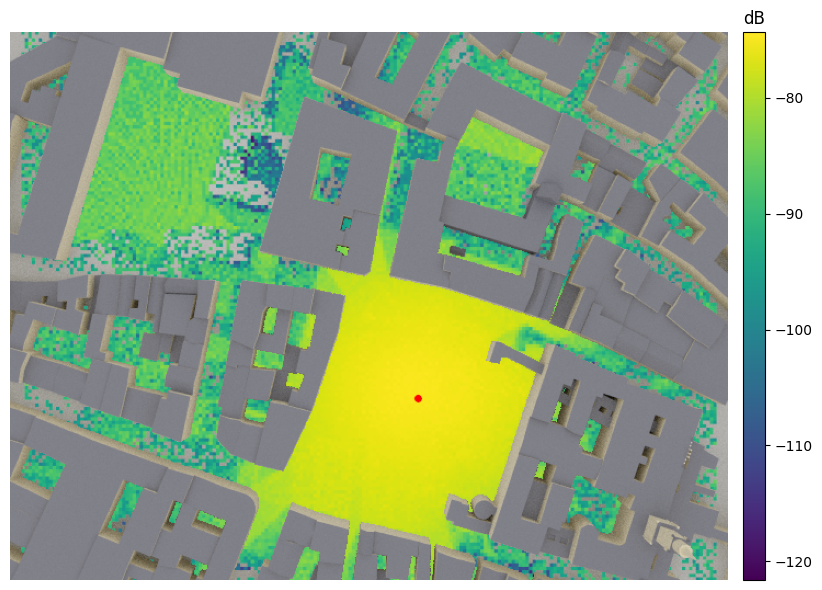

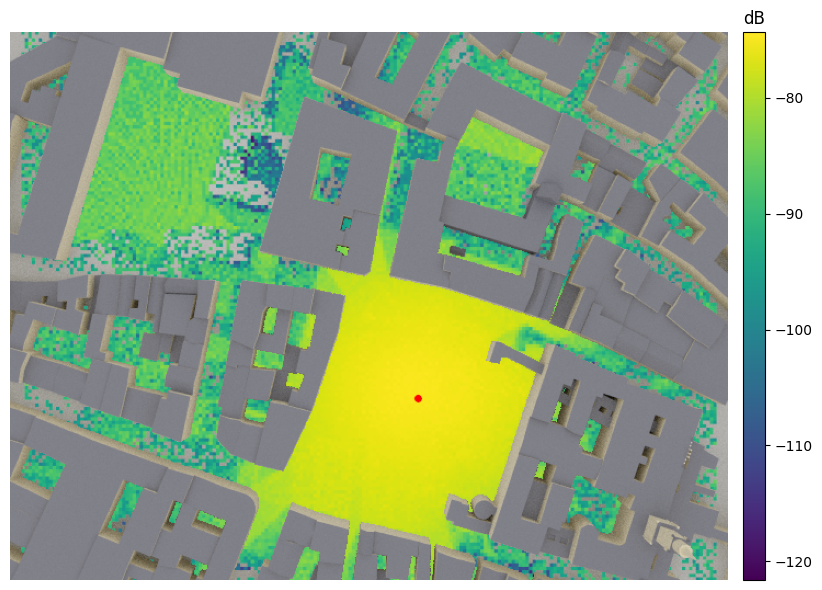

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# (필수) 라디오맵 파라미터
map_center = [100.0, 100.0, 1.5]
map_size = [400.0, 400.0]
map_orientation = 0.0
cell_size = [2.0, 2.0]

# (필수) RadioMapSolver 인스턴스 한 번 생성
# from sionna.rt import RadioMapSolver  가 이미 되어 있어야 합니다.
rm_solver = RadioMapSolver()

# 1. 송신기 위치/출력 재설정
scene.transmitters["BaseStation"].position = [53, 75, 60]  # 높이 60m
scene.transmitters["BaseStation"].power_dbm = 60             # 출력 상향

# 2. 라디오맵 계산
print("Generating Radio Map (RSS)...")
rm = rm_solver(
    scene=scene,
    max_depth=5,
    center=map_center,
    size=map_size,
    orientation=map_orientation,
    cell_size=cell_size
)

# 3. dBm 범위 계산 (색상 스케일용)
rss_watt = np.squeeze(rm.rss.numpy())
rss_dbm = 10 * np.log10(np.maximum(rss_watt, 1e-20)) + 30

vmin = np.min(rss_dbm)
vmax = np.max(rss_dbm)
display_vmin = max(vmin, -120)

print(f"RSS Range: {vmin:.2f} dBm ~ {vmax:.2f} dBm")

# 4. 뮌헨 씬 위에 라디오맵을 한 번에 렌더
print("Rendering Radio Map over Munich Scene...")

print("Rendering Radio Map over Munich Scene...")

scene.render(
    camera=bird_cam,
    radio_map=rm,          # 계산된 라디오맵
    show_devices=True,     # 기지국 빨간 점 표시
    rm_show_color_bar=True, # 이거 하나만 추가! (색 막대)
    rm_cmap="viridis"
)


Loading Scene...
Generating Trajectory...
Generated 100 trajectory points.
Starting Simulation Loop...
Rendering at step 0, Rx position: [114.77234   64.515335   1.5     ]
 -> Found 62 paths


<Figure size 800x800 with 0 Axes>

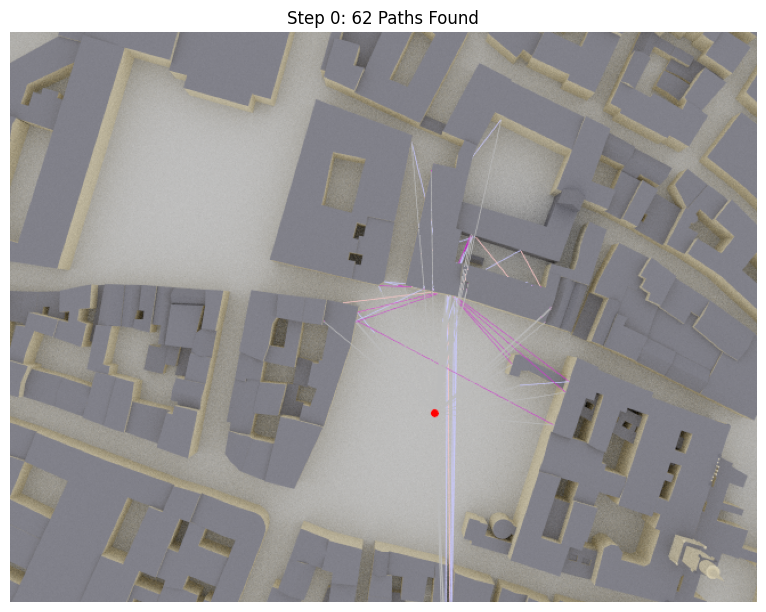

Processed 0/100 steps...
Processed 20/100 steps...
Processed 40/100 steps...
Processed 60/100 steps...
Processed 80/100 steps...
Rendering at step 99, Rx position: [112.83261  64.91264   1.5    ]
 -> Found 64 paths


<Figure size 800x800 with 0 Axes>

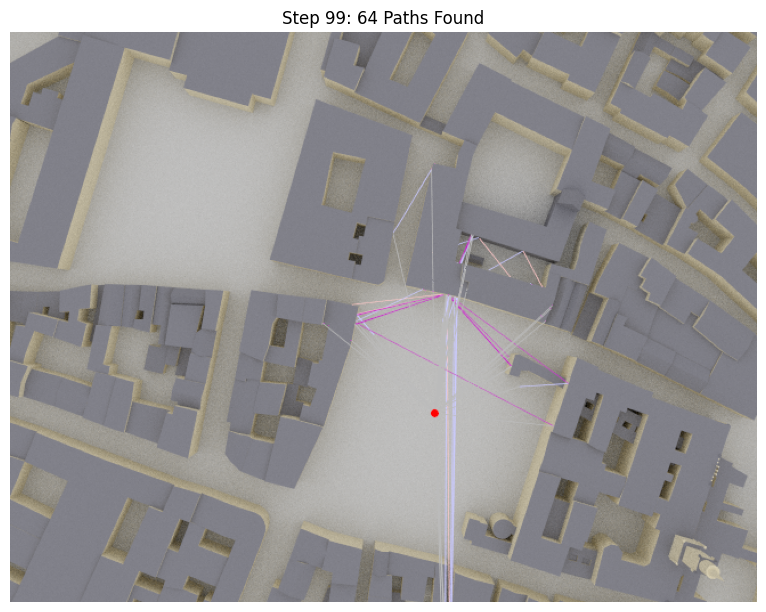

Simulation Complete. Collected 100 CIR snapshots and 100 CFR snapshots.

=== Trajectory positions and velocities ===
Step   0: pos = [114.77234   64.515335   1.5     ], vel = [-1.9592285   0.40130615  0.        ]
Step   1: pos = [114.75275  64.51935   1.5    ], vel = [-1.9592285   0.40130615  0.        ]
Step   2: pos = [114.733154  64.52336    1.5     ], vel = [-1.9592285   0.40130615  0.        ]
Step   3: pos = [114.71356   64.527374   1.5     ], vel = [-1.9592285   0.40130615  0.        ]
Step   4: pos = [114.69397  64.53139   1.5    ], vel = [-1.9592285   0.40130615  0.        ]
Step   5: pos = [114.67438  64.5354    1.5    ], vel = [-1.9592285   0.40130615  0.        ]
Step   6: pos = [114.654785  64.53941    1.5     ], vel = [-1.9592285   0.40130615  0.        ]
Step   7: pos = [114.63519  64.54343   1.5    ], vel = [-1.9599915  0.4020691  0.       ]
Step   8: pos = [114.61559  64.54745   1.5    ], vel = [-1.9592285   0.40130615  0.        ]
Step   9: pos = [114.596    64.55146 

In [46]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import drjit as dr
import gc

# Sionna 라이브러리 임포트
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera, PathSolver
from sionna.rt import scene as share_scene

# 1. 메모리 정리
gc.collect()
try:
    dr.flush_malloc_cache()
except:
    pass

# 2. 씬 로드 및 설정 (Munich)
print("Loading Scene...")
scene = load_scene(share_scene.munich)
scene.frequency = 2.4e9
scene.synthetic_array = False

# 안테나 설정
scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")
scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")

# 송신기 배치 (80m 높이)
if "BaseStation" in scene.transmitters:
    scene.remove("BaseStation")
tx = Transmitter(name="BaseStation", position=[53, 75, 60], orientation=[0, 0, 0], display_radius=2.0)
scene.add(tx)
tx.array = scene.tx_array
tx.power_dbm = 40

# 카메라 설정 (500m 고도에서 100,100 지점 바라보기)
bird_cam = Camera(position=[100, 100, 500], look_at=[100, 100, 0])

# -------------------------------------------------------------------------
# 3. Random Waypoint 생성 함수 (100 스텝용으로 수정)
# -------------------------------------------------------------------------
def generate_random_waypoint_trajectory(
    area_bounds=[[80, 120], [80, 120]],  # Munich 송신기 근처 40x40m 영역
    height=1.5,
    v=2.0,           # 리시버 속도 [m/s]  ★ 2 m/s로 설정
    num_steps=100,   # ★ 스텝 수 고정
    dt=0.01,         # 시간 간격 [s] → 100 스텝이면 총 1초
    threshold=1.0
):
    """
    Random waypoint 궤적 생성.
    num_steps, dt로 총 시뮬레이션 시간은 num_steps * dt 초.
    """
    positions = []

    # 초기 위치 랜덤 설정
    x = np.random.uniform(area_bounds[0][0], area_bounds[0][1])
    y = np.random.uniform(area_bounds[1][0], area_bounds[1][1])
    pos = np.array([x, y])

    goal = None

    for _ in range(num_steps):
        if goal is None or np.linalg.norm(goal - pos) < threshold:
            # 새 목표 지점 샘플링
            gx = np.random.uniform(area_bounds[0][0], area_bounds[0][1])
            gy = np.random.uniform(area_bounds[1][0], area_bounds[1][1])
            goal = np.array([gx, gy])

            direction = goal - pos
            norm = np.linalg.norm(direction)
            if norm > 0:
                direction /= norm
            else:
                direction = np.zeros(2)

        # 이동 (속도 v, 시간간격 dt)
        pos = pos + v * dt * direction
        positions.append([pos[0], pos[1], height])

    return np.array(positions, dtype=np.float32), dt

# 4. 궤적 및 속도 생성
print("Generating Trajectory...")
traj_positions, sim_dt = generate_random_waypoint_trajectory(
    area_bounds=[[80, 120], [0, 120]],
    v=2.0,           # ★ 2 m/s
    num_steps=100,   # ★ 100 스텝
    dt=0.01          # 10 ms 간격 → 총 1초
)
print(f"Generated {len(traj_positions)} trajectory points.")

# Velocity 추출 (finite difference)
velocities = (traj_positions[1:] - traj_positions[:-1]) / sim_dt
velocities = np.vstack([velocities, velocities[-1]])  # 마지막 스텝은 앞 스텝과 동일하게

# 5. 시뮬레이션 루프
path_solver = PathSolver()

cir_list = []   # (a, tau) CIR 데이터 저장
cfr_list = []   # CFR 데이터 저장

# CFR 계산용 파라미터 (예: 20 MHz 대역, 64 서브캐리어)
num_subcarriers = 64
bandwidth = 20e6  # 20 MHz
subcarrier_freqs = scene.frequency + np.linspace(
    -bandwidth/2, bandwidth/2, num_subcarriers
)

# 시각화: 0번, 마지막 스텝만 렌더링 (원하면 수정)
render_indices = [0, len(traj_positions)-1]

print("Starting Simulation Loop...")

for i, pos in enumerate(traj_positions):
    # 메모리 정리
    if i % 10 == 0:
        gc.collect()
        try:
            dr.flush_malloc_cache()
        except:
            pass

    # 수신기 재배치
    if "mobile_rx" in scene.receivers:
        scene.remove("mobile_rx")

    rx = Receiver(name="mobile_rx", position=pos.tolist(),
                  orientation=[0, 0, 0], display_radius=1.0)
    scene.add(rx)
    scene.get("BaseStation").look_at(rx)

    # 속도 부여 (Doppler 반영)
    rx.velocity = velocities[i].tolist()

    try:
        # Ray Tracing 수행
        paths = path_solver(
            scene=scene,
            max_depth=5,
            samples_per_src=10 ** 6,
            los=True,
            specular_reflection=True,
            diffuse_reflection=True,
            refraction=True,
            synthetic_array=False,
            diffraction=True,
            edge_diffraction=True,
            diffraction_lit_region=True,
            seed=42
        )

        # 선택된 스텝만 경로 시각화
        if i in render_indices:
            a_check, _ = paths.cir(normalize_delays=True)
            a_check = a_check.numpy() if hasattr(a_check, "numpy") else np.array(a_check)
            num_paths_found = a_check.shape[-2]

            print(f"Rendering at step {i}, Rx position: {pos}")
            print(f" -> Found {num_paths_found} paths")

            plt.figure(figsize=(8, 8))
            if num_paths_found > 0:
                scene.render(camera=bird_cam, paths=paths, show_devices=True)
                plt.title(f"Step {i}: {num_paths_found} Paths Found")
            else:
                scene.render(camera=bird_cam, show_devices=True)
                plt.title("No Paths Found")
            plt.show()

        # ----------------------
        # CIR 수집
        # ----------------------
        a, tau = paths.cir(normalize_delays=True)
        a_np = a.numpy() if hasattr(a, "numpy") else np.array(a)
        tau_np = tau.numpy() if hasattr(tau, "numpy") else np.array(tau)
        cir_list.append((a_np, tau_np))

        # ----------------------
        # CFR 수집
        # ----------------------
        h_f = paths.cfr(subcarrier_freqs)
        h_f_np = h_f.numpy() if hasattr(h_f, "numpy") else np.array(h_f)
        cfr_list.append(h_f_np)

    except Exception as e:
        print(f"Error at step {i}: {e}")
        break

    if i % 20 == 0:
        print(f"Processed {i}/{len(traj_positions)} steps...")

print(f"Simulation Complete. Collected {len(cir_list)} CIR snapshots and {len(cfr_list)} CFR snapshots.")

# -------------------------------------------------------------------------
# 6. traj_positions[i], velocities[i] 출력
# -------------------------------------------------------------------------
print("\n=== Trajectory positions and velocities ===")
for i in range(len(traj_positions)):
    print(f"Step {i:3d}: pos = {traj_positions[i]}, vel = {velocities[i]}")


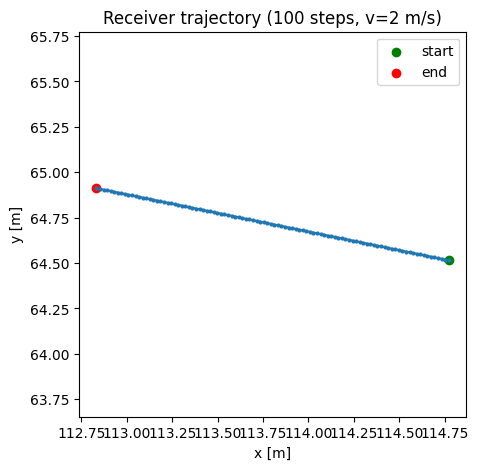

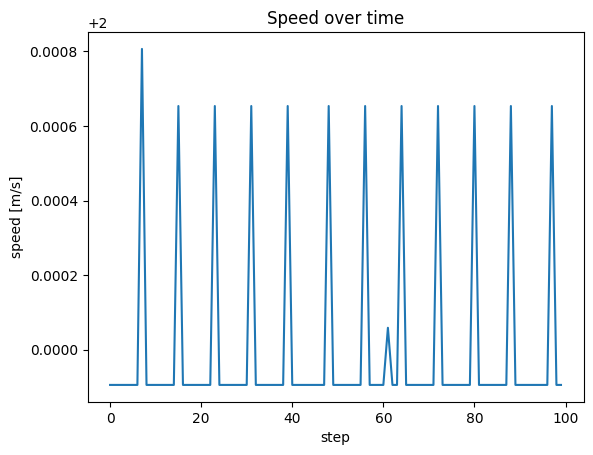

In [48]:
# 2D 평면에서 궤적 확인
plt.figure(figsize=(5, 5))
plt.plot(traj_positions[:,0], traj_positions[:,1], marker='o', markersize=2)
plt.scatter(traj_positions[0,0], traj_positions[0,1], c='g', label='start')
plt.scatter(traj_positions[-1,0], traj_positions[-1,1], c='r', label='end')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Receiver trajectory (100 steps, v=2 m/s)')
plt.legend()
plt.axis('equal')
plt.show()

# 속도 크기 확인
speed = np.linalg.norm(velocities[:,:2], axis=1)
plt.figure()
plt.plot(speed)
plt.xlabel('step')
plt.ylabel('speed [m/s]')
plt.title('Speed over time')
plt.show()


Plotting CIR (Magnitude) for the last receiver position...
Raw Data Shape - Gain: (2, 1, 1, 1, 1, 64, 1), Delay: (1, 1, 1, 1, 64)


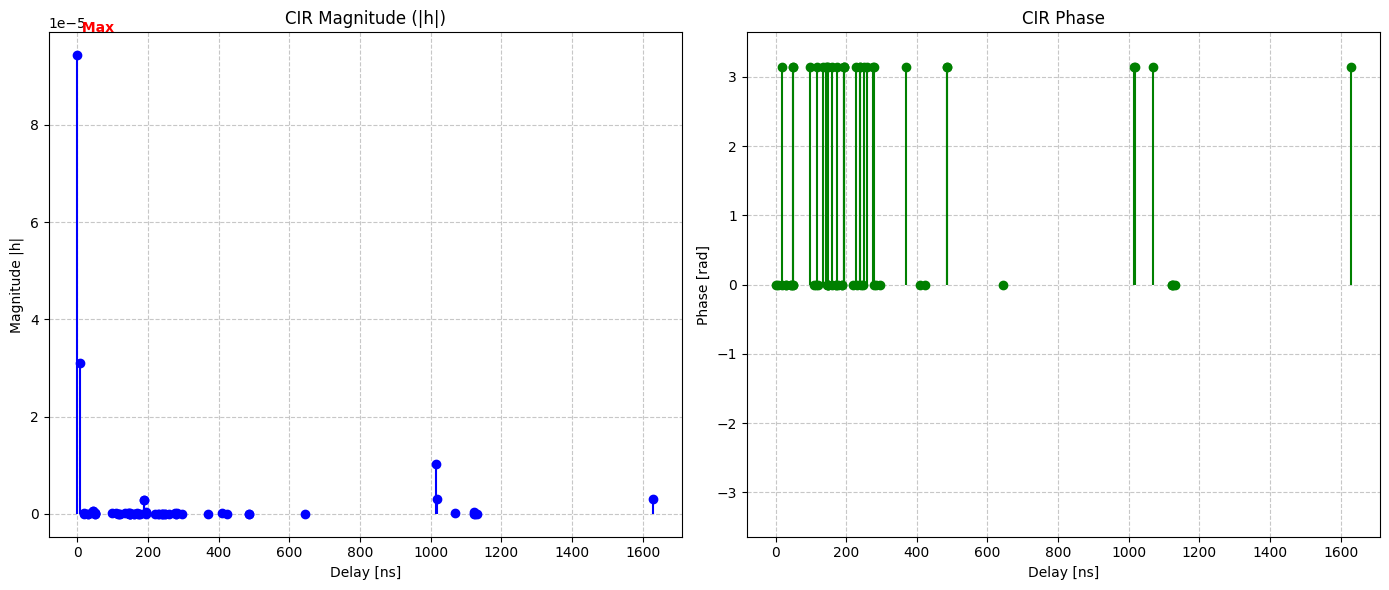


--- Path Details (Top 5 Strongest) ---
Delay:    0.00 ns | Mag: 0.000094 | Power: -50.51 dBm | Phase:  0.00 rad
Delay:    7.04 ns | Mag: 0.000031 | Power: -60.19 dBm | Phase:  0.00 rad
Delay: 1014.96 ns | Mag: 0.000010 | Power: -69.86 dBm | Phase:  3.14 rad
Delay: 1629.81 ns | Mag: 0.000003 | Power: -80.28 dBm | Phase:  3.14 rad
Delay: 1016.50 ns | Mag: 0.000003 | Power: -80.55 dBm | Phase:  3.14 rad


In [49]:
import matplotlib.pyplot as plt
import numpy as np

# 6. CIR & Phase 그래프 그리기 (절댓값 버전)

print(f"Plotting CIR (Magnitude) for the last receiver position...")

# 1) CIR 데이터 추출
a, tau = paths.cir(normalize_delays=True)

# 2) 데이터 형 변환
if isinstance(a, (list, tuple)):
    a_np = np.array(a)
else:
    a_np = a.numpy()

if isinstance(tau, (list, tuple)):
    tau_np = np.array(tau)
else:
    tau_np = tau.numpy()

print(f"Raw Data Shape - Gain: {a_np.shape}, Delay: {tau_np.shape}")

# 3) 차원 맞추기
delay = tau_np.flatten()
num_paths = delay.shape[0]
gain_flat = a_np.flatten()

if gain_flat.size == num_paths:
    gain = gain_flat
elif gain_flat.size > num_paths:
    print(f"Warning: Gain has more elements ({gain_flat.size}) than Delay ({num_paths}). Using first {num_paths} elements.")
    gain = gain_flat[:num_paths]
else:
    print("Error: Gain has fewer elements than Delay. Cannot plot.")
    gain = np.zeros_like(delay)

# 4) 유효하지 않은 경로(0) 제거
valid_indices = np.where(np.abs(gain) > 1e-12)
gain = gain[valid_indices]
delay = delay[valid_indices] * 1e9 # s -> ns

# 5) Magnitude(절댓값) & Phase 계산
# [수정됨] 절댓값(|h|) 계산
magnitude = np.abs(gain) 

# (참고용) 텍스트 출력을 위해 dBm도 계산해둡니다.
power_watt = magnitude**2
power_dbm = 10 * np.log10(np.maximum(power_watt, 1e-20)) + 30
phase_rad = np.angle(gain)

# 6) 그래프 그리기
if len(delay) == 0:
    print("No valid paths found to plot (All powers are zero).")
else:
    plt.figure(figsize=(14, 6))

    # --- [그래프 1] CIR Magnitude (|h|) ---
    plt.subplot(1, 2, 1)
    # [수정됨] power_dbm 대신 magnitude 사용
    markerline, stemlines, baseline = plt.stem(delay, magnitude, linefmt='b-', markerfmt='bo', basefmt=" ")
    plt.setp(baseline, visible=False) 
    
    plt.title("CIR Magnitude (|h|)") # 제목 변경
    plt.xlabel("Delay [ns]")
    plt.ylabel("Magnitude |h|")      # Y축 라벨 변경
    plt.grid(True, linestyle='--', alpha=0.7)

    # 가장 강한 신호 표시
    if len(magnitude) > 0:
        max_idx = np.argmax(magnitude)
        # 텍스트 위치를 magnitude 기준으로 조금 위로 설정 (1.05배)
        plt.text(delay[max_idx], magnitude[max_idx] * 1.05, " Max", color='red', fontweight='bold')

    # --- [그래프 2] Phase Profile ---
    plt.subplot(1, 2, 2)
    plt.stem(delay, phase_rad, linefmt='g-', markerfmt='go', basefmt=" ")
    plt.title("CIR Phase")
    plt.xlabel("Delay [ns]")
    plt.ylabel("Phase [rad]")
    plt.ylim([-np.pi-0.5, np.pi+0.5])
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    # 상세 정보 출력 (여전히 dBm 정보는 유용하므로 함께 출력)
    print("\n--- Path Details (Top 5 Strongest) ---")
    sorted_indices = np.argsort(magnitude)[::-1] # 크기순 정렬
    for i in sorted_indices[:5]:
        print(f"Delay: {delay[i]:7.2f} ns | Mag: {magnitude[i]:.6f} | Power: {power_dbm[i]:6.2f} dBm | Phase: {phase_rad[i]:5.2f} rad")

Calculating Channel Frequency Response (CFR)...
Raw h_freq shape: (1, 1, 1, 1, 1, 64)
--- CFR Stats ---
Max Gain: -76.08 dB
Min Gain: -80.28 dB
Fading Depth: 4.20 dB


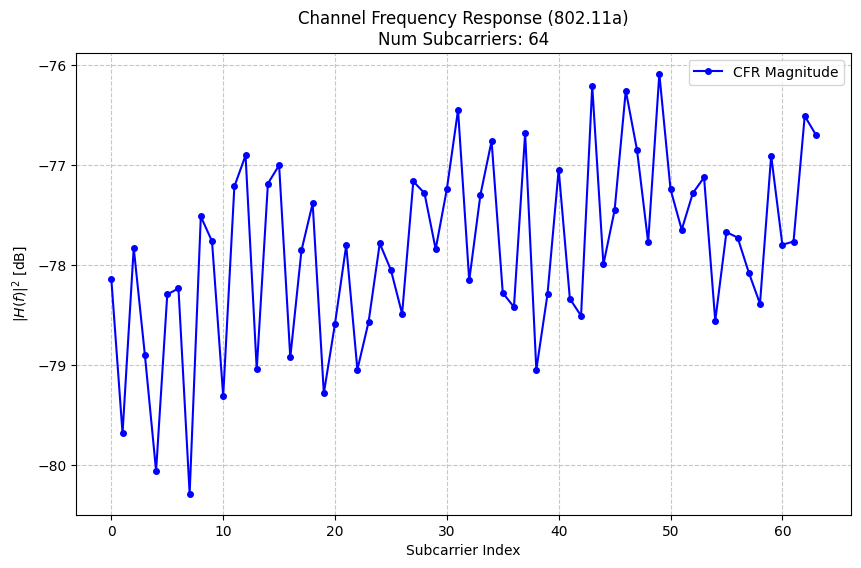

In [50]:
import matplotlib.pyplot as plt
import numpy as np
from sionna.rt.utils import subcarrier_frequencies

# 7. OFDM 채널 주파수 응답 (CFR) 분석 (수정됨)

print("Calculating Channel Frequency Response (CFR)...")

# 1. OFDM 파라미터 설정
num_subcarriers = 64            
subcarrier_spacing = 312.5e3    

# 2. 주파수 그리드 생성
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

# 3. CFR 계산
# paths는 이전 단계에서 계산된 경로 객체입니다.
# [수정] out_type="numpy"를 추가하여 바로 Numpy 배열로 받습니다.
try:
    h_freq = paths.cfr(
        frequencies=frequencies,
        normalize=False,
        normalize_delays=True,
        out_type="numpy" 
    )
except TypeError:
    # out_type 옵션을 지원하지 않는 구버전일 경우
    h_freq = paths.cfr(
        frequencies=frequencies,
        normalize=False,
        normalize_delays=True
    )

# 4. 데이터 전처리 (Tuple/Tensor 처리)
# 반환값이 튜플인 경우 (h, ) 형태일 수 있으므로 꺼냅니다.
if isinstance(h_freq, tuple):
    h_freq = h_freq[0]

# 텐서인 경우 Numpy로 변환
if not isinstance(h_freq, np.ndarray):
    if hasattr(h_freq, 'numpy'):
        h_freq = h_freq.numpy()
    else:
        h_freq = np.array(h_freq)

print(f"Raw h_freq shape: {h_freq.shape}")

# 차원 축소: [batch, rx, rx_ant, tx, tx_ant, steps, subcarriers] -> [subcarriers]
# flatten()을 사용하여 1차원으로 폅니다.
h_freq_1d = h_freq.flatten()

# 데이터가 중복되어(배치 사이즈 등으로 인해) 서브캐리어 수보다 많으면 앞부분만 자릅니다.
if h_freq_1d.size > num_subcarriers:
    h_freq_1d = h_freq_1d[:num_subcarriers]

# 5. 전력(Power) 계산 및 dB 변환
power_linear = np.abs(h_freq_1d)**2
power_db = 10 * np.log10(np.maximum(power_linear, 1e-20)) 

# 6. 시각화
plt.figure(figsize=(10, 6))
plt.plot(power_db, marker='o', markersize=4, linestyle='-', color='b', label='CFR Magnitude')
plt.xlabel("Subcarrier Index")
plt.ylabel(r"$|H(f)|^2$ [dB]")
plt.title(f"Channel Frequency Response (802.11a)\nNum Subcarriers: {num_subcarriers}")
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend()

print(f"--- CFR Stats ---")
if len(power_db) > 0:
    print(f"Max Gain: {np.max(power_db):.2f} dB")
    print(f"Min Gain: {np.min(power_db):.2f} dB")
    print(f"Fading Depth: {np.max(power_db) - np.min(power_db):.2f} dB")

plt.show()

Calculating Discrete Channel Taps...
Channel Bandwidth: 20.00 MHz
Shape of taps:  (1, 1, 1, 1, 1, 107)


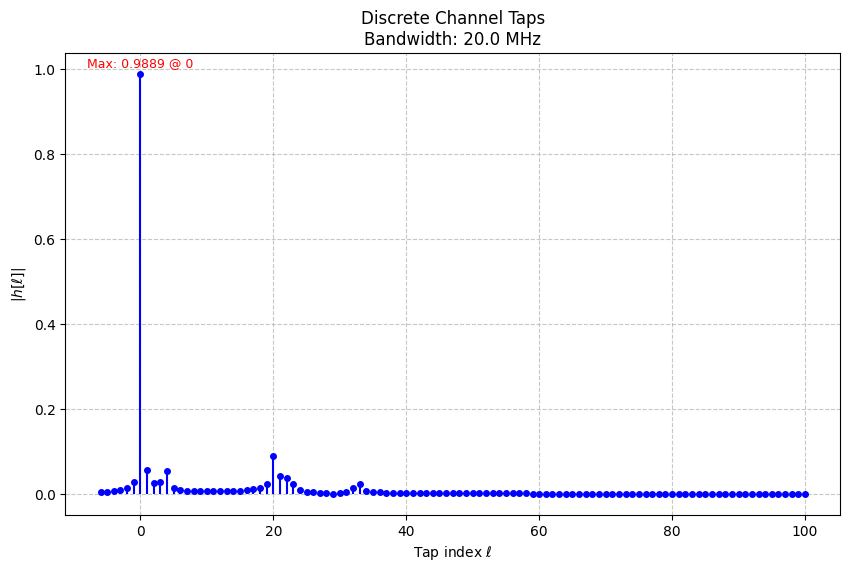

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# 8. Discrete Channel Taps 시각화

print("Calculating Discrete Channel Taps...")

# 1. 대역폭 계산
# OFDM 대역폭 = 부반송파 개수 * 부반송파 간격
ch_bandwidth = num_subcarriers * subcarrier_spacing
print(f"Channel Bandwidth: {ch_bandwidth / 1e6:.2f} MHz")

# 2. Taps 계산 (paths 객체 사용)
# l_min, l_max: 탭의 인덱스 범위 (음수 인덱스는 non-causal 성분이나 동기화 오차 등을 표현할 때 사용됨)
taps = paths.taps(
    bandwidth=ch_bandwidth,
    l_min=-6, 
    l_max=100,
    normalize=True,
    normalize_delays=True,
    out_type="numpy"
)

# Shape 확인: [batch, rx, rx_ant, tx, tx_ant, num_taps]
print("Shape of taps: ", taps.shape)

# 3. 데이터 전처리 (1차원으로 추출)
# 첫 번째 배치, 첫 번째 수신기/송신기/안테나의 탭 응답을 가져옵니다.
# taps[0, 0, 0, 0, 0, :] -> shape (107,)
h_taps = np.abs(taps)[0, 0, 0, 0, 0, :]
tap_indices = np.arange(-6, 101)

# 4. 시각화 (Stem Plot)
plt.figure(figsize=(10, 6))

# 줄기 그래프 그리기
markerline, stemlines, baseline = plt.stem(tap_indices, h_taps, basefmt=" ", linefmt='b-', markerfmt='bo')
plt.setp(markerline, markersize=4)

plt.xlabel(r"Tap index $\ell$")
plt.ylabel(r"|$h[\ell]|$")
plt.title(f"Discrete Channel Taps\nBandwidth: {ch_bandwidth/1e6:.1f} MHz")
plt.grid(True, which='both', linestyle='--', alpha=0.7)

# 가장 강한 탭 표시
max_idx = np.argmax(h_taps)
max_tap = tap_indices[max_idx]
max_val = h_taps[max_idx]
plt.text(max_tap, max_val + 0.01 * max_val, f"Max: {max_val:.4f} @ {max_tap}", 
         ha='center', va='bottom', color='red', fontsize=9)

plt.show()

Calculating Time-Varying Channel Frequency Response...
Original Shape of b_mob:  (1, 1, 1, 1, 100, 64)
Squeezed Shape (Time, Freq):  (100, 64)


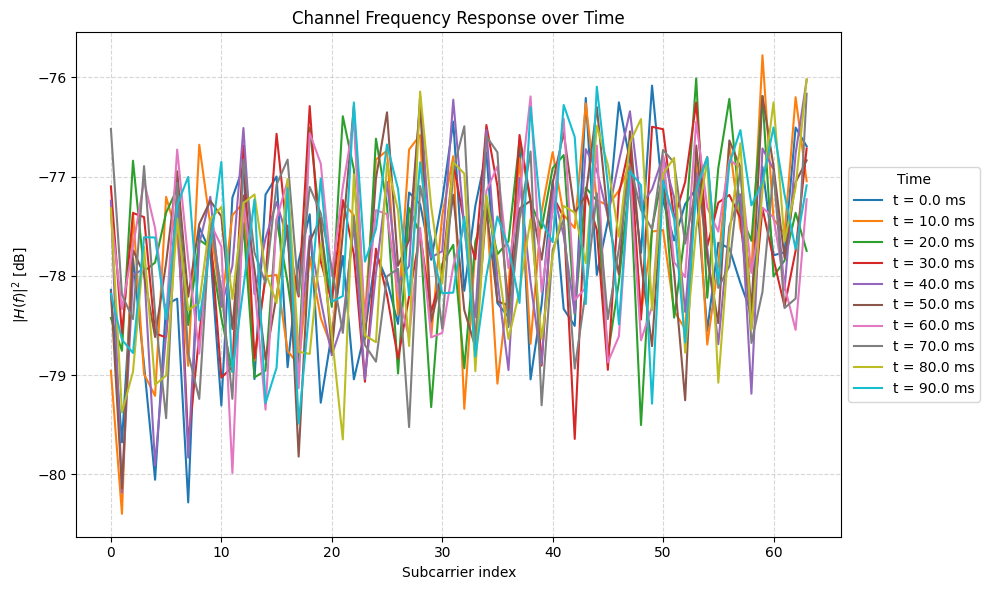

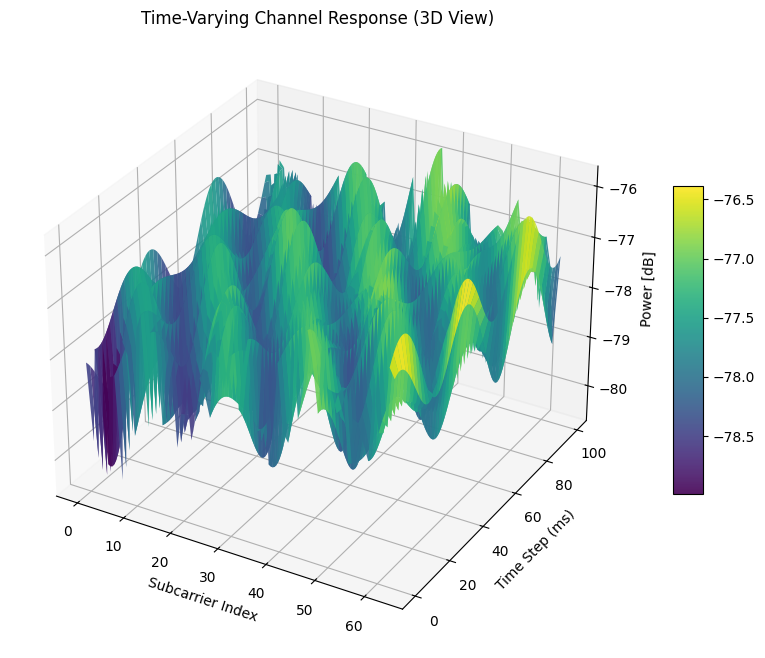


Generating Dataset...
Dataset Saved: csi_dataset.npz
Input X shape: (90, 10, 64) (Samples, Seq_Len, Subcarriers)
Label y shape: (90, 64) (Samples, Subcarriers)
File saved locally. Please check your directory.


In [52]:
import matplotlib.pyplot as plt
import numpy as np
from sionna.rt.utils import subcarrier_frequencies

# 7. Time-Variant CFR (시간에 따른 주파수 응답 변화) - 에러 수정 및 데이터셋 저장

print("Calculating Time-Varying Channel Frequency Response...")

# 1. 시뮬레이션 파라미터 설정 (이전 단계와 동일 가정)
num_subcarriers = 64
subcarrier_spacing = 312.5e3
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)
sampling_frequency = 1000.0  # 1kHz
num_time_steps = 100         # 100ms

# 2. CFR 계산
# out_type="numpy"로 바로 Numpy 배열 획득 시도
try:
    b_mob = paths.cfr(
        frequencies=frequencies,
        sampling_frequency=sampling_frequency,
        num_time_steps=num_time_steps,
        out_type="numpy"
    )
except TypeError:
    # 구버전 호환성
    b_mob = paths.cfr(
        frequencies=frequencies,
        sampling_frequency=sampling_frequency,
        num_time_steps=num_time_steps
    )
    if isinstance(b_mob, tuple): b_mob = b_mob[0]
    if hasattr(b_mob, 'numpy'): b_mob = b_mob.numpy()
    else: b_mob = np.array(b_mob)

print("Original Shape of b_mob: ", b_mob.shape)

# [핵심 수정] 불필요한 차원 제거 (Squeeze)
# (1, 1, 1, 1, 100, 64) -> (100, 64) 로 변환
# 이렇게 하면 [time_steps, subcarriers] 형태가 됩니다.
cfr_2d = np.squeeze(b_mob)

print("Squeezed Shape (Time, Freq): ", cfr_2d.shape)


# 3. 2D 시각화: 시간 흐름에 따른 주파수 응답 스냅샷
plt.figure(figsize=(10, 6))

# Power [dB] 계산
cfr_power_db = 10 * np.log10(np.abs(cfr_2d)**2 + 1e-20)

# 10 스텝 간격으로 그리기
for idx in range(0, num_time_steps, 10):
    time_ms = idx / sampling_frequency * 1000
    plt.plot(cfr_power_db[idx, :], label=f't = {time_ms:.1f} ms')

plt.xlabel("Subcarrier index")
plt.ylabel(r"$|H(f)|^2$ [dB]")
plt.title("Channel Frequency Response over Time")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Time")
plt.tight_layout()
plt.show()


# 4. 3D Surface 시각화 (전체적인 변화 확인)
try:
    from mpl_toolkits.mplot3d import Axes3D
    
    X, Y = np.meshgrid(np.arange(num_subcarriers), np.arange(num_time_steps))
    
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # (Time, Freq) 2D 배열을 3D 표면으로 플롯
    surf = ax.plot_surface(X, Y, cfr_power_db, cmap='viridis', edgecolor='none', alpha=0.9)
    
    ax.set_xlabel('Subcarrier Index')
    ax.set_ylabel('Time Step (ms)')
    ax.set_zlabel('Power [dB]')
    ax.set_title('Time-Varying Channel Response (3D View)')
    fig.colorbar(surf, shrink=0.5, aspect=10)
    plt.show()
except Exception as e:
    print(f"3D plot skipped: {e}")


# 5. 데이터셋 생성 및 저장 (Sliding Window)
# 과거 10개의 CSI를 보고 미래 1개의 CSI를 예측하는 데이터셋 생성
print("\nGenerating Dataset...")

seq_len = 10       # 과거 10ms
pred_horizon = 1   # 미래 1ms 예측

X_data, y_data = [], []
# 슬라이딩 윈도우
for t in range(len(cfr_2d) - seq_len - pred_horizon + 1):
    X_data.append(cfr_2d[t : t + seq_len])                # 입력: (10, 64)
    y_data.append(cfr_2d[t + seq_len + pred_horizon - 1]) # 정답: (64,)

X_data = np.stack(X_data)
y_data = np.stack(y_data)

# 파일 저장
np.savez("csi_dataset.npz", data=X_data.astype(np.complex64), labels=y_data.astype(np.complex64))
print(f"Dataset Saved: csi_dataset.npz")
print(f"Input X shape: {X_data.shape} (Samples, Seq_Len, Subcarriers)")
print(f"Label y shape: {y_data.shape} (Samples, Subcarriers)")

# 다운로드 (Colab용)
try:
    from google.colab import files
    files.download("csi_dataset.npz")
except ImportError:
    print("File saved locally. Please check your directory.")

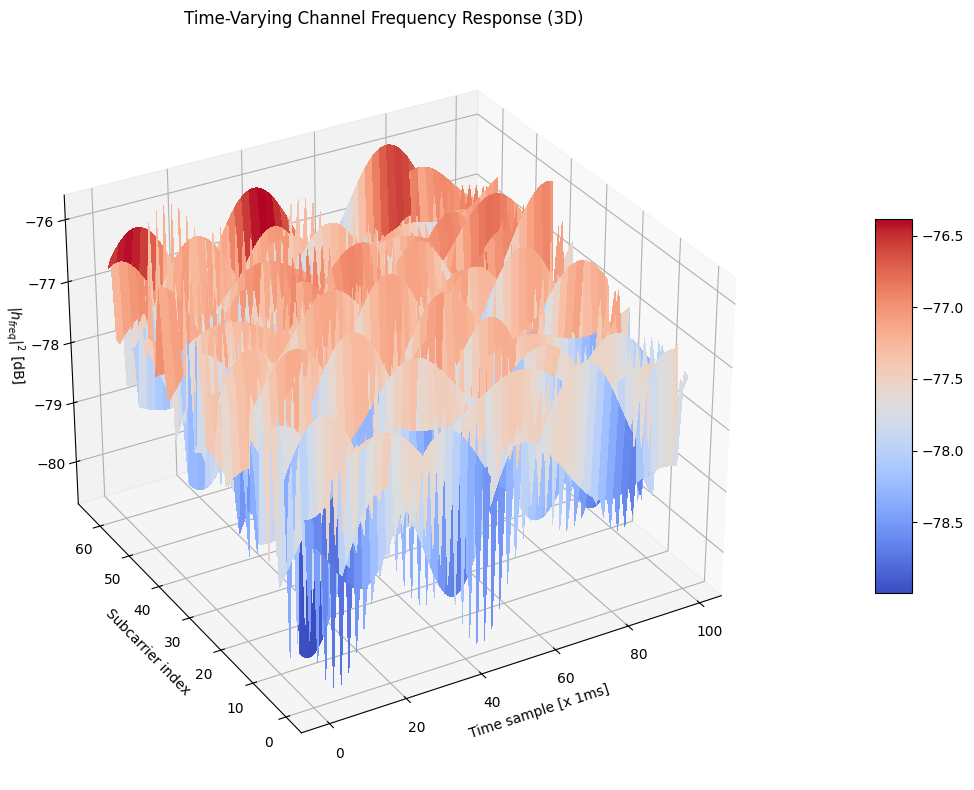

In [53]:
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np

# 1. 3D 플롯을 위한 데이터 준비
# b_mob shape: (1, 1, 1, 1, 100, 64) -> (Batch, Rx, Tx_batch, Tx, Time, Subcarrier)
num_time_steps = b_mob.shape[4]
num_subcarriers = b_mob.shape[5]

# X, Y 축 격자 생성 (Time, Subcarrier)
X = np.arange(0, num_time_steps)     # 시간 축 (0 ~ 99)
Y = np.arange(0, num_subcarriers)    # 주파수(서브캐리어) 축 (0 ~ 63)
X, Y = np.meshgrid(X, Y)             # 2D 그리드 생성 (shape: 64x100)

# Z 축 데이터 (CFR Power in dB)
# Z 배열 초기화: (Subcarrier, Time) 크기인 (64, 100)
Z = np.zeros((num_subcarriers, num_time_steps))

# 각 시간 스텝별로 모든 서브캐리어의 전력(dB) 계산하여 채움
for t in range(num_time_steps):
    # b_mob[0,0,0,0,t,:] : t 시점의 64개 서브캐리어 복소 이득
    power = np.abs(b_mob[0, 0, 0, 0, t, :]) ** 2
    Z[:, t] = 10 * np.log10(power + 1e-20)  # log(0) 방지용 엡실론 추가

# 2. 3D Surface Plot 그리기
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 서피스 플롯 생성
surf = ax.plot_surface(X, Y, Z,
                       cmap=cm.coolwarm,
                       linewidth=0,
                       antialiased=False)

# 축 레이블 설정
ax.set_xlabel("Time sample [x 1ms]")
ax.set_ylabel("Subcarrier index")
ax.set_zlabel(r"$|h_{freq}|^2$ [dB]")
ax.set_title("Time-Varying Channel Frequency Response (3D)")

# 컬러바 추가
fig.colorbar(surf, shrink=0.5, aspect=10, pad=0.1)

# 시각화 각도 조정 (선택 사항)
ax.view_init(elev=30, azim=-120)

plt.tight_layout()
plt.show()

In [54]:
import scipy.io
import numpy as np
from sionna.rt.utils import subcarrier_frequencies

# 1. 저장할 데이터 계산 (CFR & CIR)
print("Generating final CSI data for export...")

# (1) 설정 확인
# 이전 단계 변수들 활용 (없으면 기본값 설정)
sim_freq = 1000.0      # Sampling Frequency (1kHz)
sim_steps = 1000       # Time Steps (1초)
n_sub = 64             # Subcarriers
sub_space = 312.5e3    # Spacing

# 주파수 축 생성
freqs = subcarrier_frequencies(n_sub, sub_space)

# (2) CFR (주파수 응답) 계산 - [Time x Frequency]
# paths는 직전 단계(Time-Evolution)에서 계산된 객체여야 합니다.
try:
    h_cfr = paths.cfr(
        frequencies=freqs,
        sampling_frequency=sim_freq,
        num_time_steps=sim_steps,
        out_type="numpy"
    )
except TypeError:
    # 구버전 호환용
    h_cfr = paths.cfr(frequencies=freqs, sampling_frequency=sim_freq, num_time_steps=sim_steps)
    if hasattr(h_cfr, 'numpy'): h_cfr = h_cfr.numpy()

# Shape 정리: [Batch, Rx, RxAnt, Tx, TxAnt, Time, Subcarrier] -> [Time, Subcarrier]
# (1x1 안테나 가정, 불필요한 차원 제거)
h_cfr_clean = np.squeeze(h_cfr) 
# 만약 차원이 안 맞으면 안전하게 reshape
if h_cfr_clean.ndim > 2:
    # Time, Subcarrier가 마지막 두 차원이라고 가정
    h_cfr_clean = h_cfr_clean.reshape(-1, n_sub)


# (3) CIR (충격 응답) 계산 - [Time x Paths]
a_cir, tau_cir = paths.cir(
    sampling_frequency=sim_freq,
    num_time_steps=sim_steps,
    normalize_delays=True
)

# Numpy 변환
if hasattr(a_cir, 'numpy'): a_cir = a_cir.numpy()
if hasattr(tau_cir, 'numpy'): tau_cir = tau_cir.numpy()

# Shape 정리: [Batch, ..., Paths, Time] -> [Time, Paths]로 변환 (CFR과 축 통일)
# a_cir 원본: [..., Paths, Time] -> Transpose -> [..., Time, Paths]
a_cir_clean = np.squeeze(a_cir)     # [Paths, Time] (보통 이렇게 나옴)
tau_cir_clean = np.squeeze(tau_cir) # [Paths] (지연시간은 시간불변 가정 시)

# 만약 a_cir_clean이 [Paths, Time] 형태라면 [Time, Paths]로 전치
if a_cir_clean.shape[0] != sim_steps and a_cir_clean.shape[-1] == sim_steps:
    a_cir_clean = a_cir_clean.T

print(f"CFR Shape: {h_cfr_clean.shape} (Time x Subcarriers)")
print(f"CIR Shape: {a_cir_clean.shape} (Time x Paths)")


# 2. 딕셔너리 생성 (MATLAB 변수명 매핑)
mat_data = {
    # --- 핵심 데이터 ---
    'CFR': h_cfr_clean,           # 복소수 주파수 응답
    'CIR_amp': a_cir_clean,       # 복소수 충격 응답 계수 (Time-Variant)
    'CIR_delay': tau_cir_clean,   # 경로별 지연 시간 (ns 단위 추천)
    
    # --- 메타 데이터 (축 정보) ---
    'time_axis': np.arange(sim_steps) / sim_freq, # 시간 축 (초)
    'freq_axis': freqs.numpy() if hasattr(freqs, 'numpy') else freqs, # 주파수 축 (Hz)
    
    # --- 설정 값 ---
    'num_subcarriers': n_sub,
    'subcarrier_spacing': sub_space,
    'sampling_frequency': sim_freq,
    'velocity': rx.velocity.numpy() if hasattr(rx.velocity, 'numpy') else rx.velocity, # 수신기 속도
    
    # --- 설명 (선택) ---
    'note': 'Sionna Ray Tracing Output: Munich Scene'
}

# 3. .mat 파일로 저장
file_name = "munich_csi_data.mat"
scipy.io.savemat(file_name, mat_data)
print(f"Successfully saved to {file_name}")

# 4. 다운로드 (Colab 등 웹 환경용)
try:
    from google.colab import files
    files.download(file_name)
except ImportError:
    print(f"File is saved in the current directory: {os.getcwd()}/{file_name}")

Generating final CSI data for export...
CFR Shape: (1000, 64) (Time x Subcarriers)
CIR Shape: (1000, 64, 2) (Time x Paths)
Successfully saved to munich_csi_data.mat
File is saved in the current directory: /home/ccs-lab/yura.min/munich_csi_data.mat


In [8]:
import os
import shutil

# 다운로드할 파일의 절대 경로
target_path = '/home/ccs-lab/yura.min/munich_csi_data.mat'
file_name = os.path.basename(target_path) # 파일명만 추출 (munich_csi_data.mat)

# 파일이 실제로 있는지 확인
if not os.path.exists(target_path):
    print(f"오류: 파일을 찾을 수 없습니다. 경로를 확인해주세요: {target_path}")
else:
    print(f"파일 확인됨: {target_path}")
    
    try:
        # -------------------------------------------------------
        # 방법 1: Google Colab 환경
        # -------------------------------------------------------
        from google.colab import files
        print("Google Colab 환경 감지됨. 다운로드를 시작합니다...")
        files.download(target_path)
        
    except ImportError:
        # -------------------------------------------------------
        # 방법 2: 일반 Jupyter Notebook / Jupyter Lab (서버)
        # -------------------------------------------------------
        print("Jupyter 환경 감지됨. 다운로드 링크를 생성합니다...")
        
        # Jupyter FileLink는 보안상 '노트북이 실행되는 폴더' 내의 파일만 접근 가능한 경우가 많습니다.
        # 따라서 파일을 현재 작업 디렉토리('./')로 복사한 후 링크를 만듭니다.
        current_dir_file = os.path.join(os.getcwd(), file_name)
        
        # 원본 파일이 현재 위치에 없다면 복사
        if os.path.abspath(target_path) != os.path.abspath(current_dir_file):
            shutil.copy(target_path, current_dir_file)
            print(f"파일을 현재 실행 경로로 복사했습니다: {current_dir_file}")
        
        # 다운로드 링크 생성
        from IPython.display import FileLink, display
        display(FileLink(file_name, result_html_prefix="클릭하여 다운로드: "))

    except Exception as e:
        print(f"다운로드 시도 중 오류 발생: {e}")
        print("-" * 50)
        print("만약 위 방법으로 안 된다면, 로컬 컴퓨터의 터미널(CMD/Powershell)에서 scp 명령어를 사용하세요:")
        print(f"scp <username>@<server_ip>:{target_path} ~/Downloads/")

파일 확인됨: /home/ccs-lab/yura.min/munich_csi_data.mat
Jupyter 환경 감지됨. 다운로드 링크를 생성합니다...


/home/ccs-lab/yura.min/munich_csi_data.mat